In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

SIM_TIME = 1000.0

LAMBDA_BASE = 5.0
MU = 6.0

SIM_TIME, LAMBDA_BASE, MU

(1000.0, 5.0, 6.0)

In [ ]:
def simulate_mm1_0(lambda_rate: float, mu_rate: float, sim_time: float, seed: int | None = None):
    np.random.seed(seed)

    env = simpy.Environment()
    server = simpy.Resource(env, capacity=1)

    stats = {
        'arrived': 0,
        'served': 0,
        'lost': 0,
        'busy_time': 0.0,
        'last_event_time': 0.0,
        'server_busy': False,
    }

    def update_busy_time():
        now = env.now
        elapsed = now - stats['last_event_time']
        if stats['server_busy']:
            stats['busy_time'] += elapsed
        stats['last_event_time'] = now

    def patient(name: int):
        nonlocal server
        stats['arrived'] += 1
        update_busy_time()

        if server.count < server.capacity:
            with server.request() as req:
                yield req
                stats['server_busy'] = True
                update_busy_time()

                service_time = np.random.exponential(1.0 / mu_rate)
                yield env.timeout(service_time)

                update_busy_time()
                stats['server_busy'] = False
                stats['served'] += 1
        else:
            stats['lost'] += 1

    def arrival_process():
        i = 0
        while True:
            interarrival = np.random.exponential(1.0 / lambda_rate)
            yield env.timeout(interarrival)
            i += 1
            env.process(patient(i))

    env.process(arrival_process())
    env.run(until=sim_time)

    arrived = stats['arrived']
    served = stats['served']
    lost = stats['lost']
    refusal_prob = lost / arrived if arrived > 0 else 0.0
    utilization = stats['busy_time'] / sim_time

    return {
        'lambda': lambda_rate,
        'mu': mu_rate,
        'sim_time': sim_time,
        'arrived': arrived,
        'served': served,
        'lost': lost,
        'refusal_prob_emp': refusal_prob,
        'utilization_emp': utilization,
    }

result_example = simulate_mm1_0(LAMBDA_BASE, MU, SIM_TIME, seed=42)
result_example

{'lambda': 5.0,
 'mu': 6.0,
 'sim_time': 1000.0,
 'arrived': 5030,
 'served': 2738,
 'lost': 2292,
 'refusal_prob_emp': 0.45566600397614315,
 'utilization_emp': 0.44403673757556406}

In [ ]:
def erlang_b_mm1_0(lambda_rate: float, mu_rate: float) -> float:
    return lambda_rate / (lambda_rate + mu_rate)

def utilization_mm1_0(lambda_rate: float, mu_rate: float) -> float:
    return lambda_rate / (lambda_rate + mu_rate)

erlang_b_mm1_0(LAMBDA_BASE, MU), utilization_mm1_0(LAMBDA_BASE, MU)

(0.45454545454545453, 0.45454545454545453)

In [ ]:
lambda_values = np.linspace(1.0, 10.0, 10)

results = []
for i, lam in enumerate(lambda_values, start=1):
    res = simulate_mm1_0(lam, MU, SIM_TIME, seed=100 + i)

    p_ref_theor = erlang_b_mm1_0(lam, MU)
    util_theor = utilization_mm1_0(lam, MU)

    res['refusal_prob_theor'] = p_ref_theor
    res['utilization_theor'] = util_theor

    results.append(res)

df_results = pd.DataFrame(results)
df_results

,lambda,mu,sim_time,arrived,served,lost,refusal_prob_emp,utilization_emp,refusal_prob_theor,utilization_theor
0,1.0,6.0,1000.0,975,842,133,0.136410,0.135234,0.142857,0.142857
1,2.0,6.0,1000.0,1928,1456,472,0.244813,0.237829,0.250000,0.250000
2,3.0,6.0,1000.0,2952,1982,970,0.328591,0.323070,0.333333,0.333333
3,4.0,6.0,1000.0,4095,2462,1632,0.398535,0.405308,0.400000,0.400000
4,5.0,6.0,1000.0,4970,2711,2259,0.454527,0.444130,0.454545,0.454545
5,6.0,6.0,1000.0,5922,3012,2909,0.491219,0.494228,0.500000,0.500000
6,7.0,6.0,1000.0,6959,3217,3741,0.537577,0.538420,0.538462,0.538462
7,8.0,6.0,1000.0,8068,3461,4606,0.570897,0.575339,0.571429,0.571429
8,9.0,6.0,1000.0,8935,3616,5319,0.595299,0.608225,0.600000,0.600000
9,10.0,6.0,1000.0,9968,3709,6259,0.627909,0.632855,0.625000,0.625000


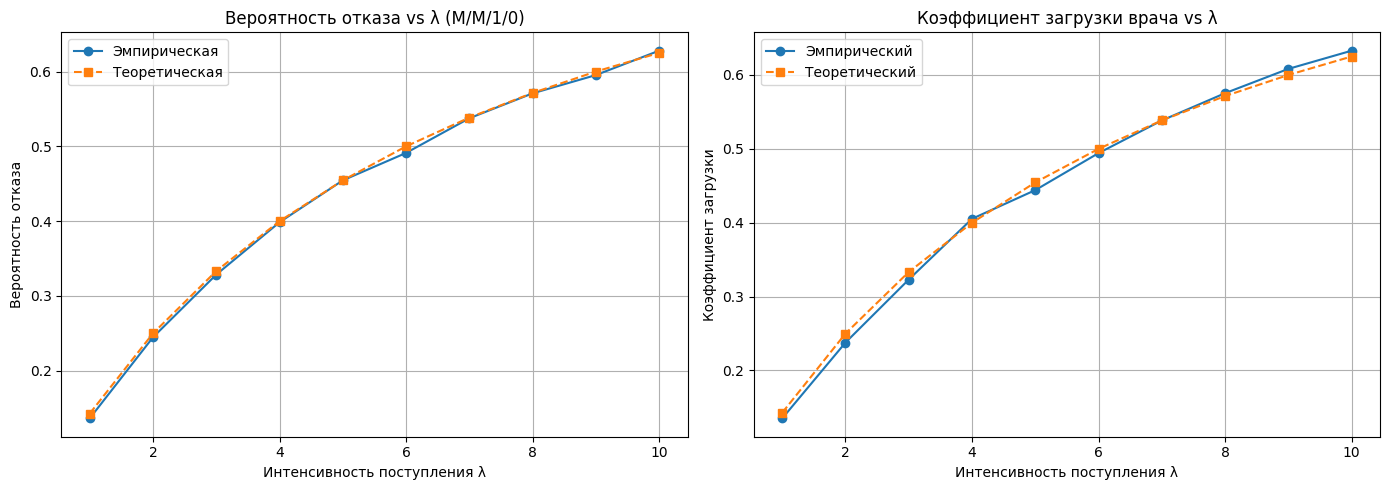

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

ax[0].plot(df_results['lambda'], df_results['refusal_prob_emp'], 'o-', label='Эмпирическая')
ax[0].plot(df_results['lambda'], df_results['refusal_prob_theor'], 's--', label='Теоретическая')
ax[0].set_xlabel('Интенсивность поступления λ')
ax[0].set_ylabel('Вероятность отказа')
ax[0].set_title('Вероятность отказа vs λ (M/M/1/0)')
ax[0].legend()

ax[1].plot(df_results['lambda'], df_results['utilization_emp'], 'o-', label='Эмпирический')
ax[1].plot(df_results['lambda'], df_results['utilization_theor'], 's--', label='Теоретический')
ax[1].set_xlabel('Интенсивность поступления λ')
ax[1].set_ylabel('Коэффициент загрузки')
ax[1].set_title('Коэффициент загрузки врача vs λ')
ax[1].legend()

plt.tight_layout()
plt.show()